# Hey Banco — Datathon 2026
## EDA UC1: Análisis de Transacciones Rechazadas por Saldo Insuficiente y Límite Excedido

**Objetivo:** Dimensionar el impacto del Caso de Uso 1 (UC1) — activación automática cuando una transacción es rechazada por saldo insuficiente o límite excedido.

| Métrica clave | Descripción |
|---------------|-------------|
| Volumen UC1 | Nº absoluto y % de rechazos resolubles automáticamente |
| Monto faltante | Monto promedio que faltó para completar la compra |
| Saldo alternativo | % de usuarios con `inversion_hey` cuyo saldo cubriría el rechazo |
| Dolor validado | % de usuarios con rechazo que contactaron a Havi |

---
**Motivos UC1:** `saldo_insuficiente` · `limite_excedido`

## 0. Setup y carga de datos

In [1]:
import subprocess, sys
# Instalar pyarrow si no está disponible en el kernel activo
try:
    import pyarrow  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 80)

STYLE = {
    'color_uc1':    '#E63946',
    'color_other':  '#A8DADC',
    'color_inv':    '#457B9D',
    'color_convs':  '#F4A261',
}

BASE_TXN  = Path(r"/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")
BASE_CONV = Path(r"/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_dataset_conversaciones 1/dataset_conversaciones")

print("Rutas:", BASE_TXN.resolve(), "|", BASE_CONV.resolve())

Rutas: /Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones | /Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_dataset_conversaciones 1/dataset_conversaciones


In [2]:
# ── hey_productos ─────────────────────────────────────────────────────────────
df_prod = pd.read_csv(
    BASE_TXN / "hey_productos.csv",
    dtype={"producto_id": str, "user_id": str, "tipo_producto": str, "estatus": str},
    parse_dates=["fecha_apertura", "fecha_ultimo_movimiento"],
)
df_prod = df_prod.drop(columns=[c for c in ["es_dato_sintetico"] if c in df_prod.columns])

# ── hey_transacciones ─────────────────────────────────────────────────────────
df_tx = pd.read_csv(
    BASE_TXN / "hey_transacciones.csv",
    dtype={
        "transaccion_id": str, "user_id": str, "producto_id": str,
        "tipo_operacion": str, "canal": str, "categoria_mcc": str,
        "ciudad_transaccion": str, "estatus": str, "motivo_no_procesada": str,
        "dia_semana": str, "dispositivo": str,
    },
    parse_dates=["fecha_hora"],
)
df_tx = df_tx.drop(columns=[c for c in ["es_dato_sintetico"] if c in df_tx.columns])

# ── dataset_50k conversaciones ────────────────────────────────────────────────
df_convs = pd.read_parquet(BASE_CONV / "dataset_50k_anonymized.parquet")
df_convs["user_id"] = df_convs["user_id"].astype(str)
df_convs["date"]    = pd.to_datetime(df_convs["date"], format="mixed")

print(f"Transacciones : {len(df_tx):>10,}")
print(f"Productos     : {len(df_prod):>10,}")
print(f"Conversaciones: {len(df_convs):>10,}")

Transacciones :    802,384
Productos     :     38,909
Conversaciones:     49,999


---
## 1. Filtrado de rechazos UC1

Extraemos todas las transacciones con `estatus = 'no_procesada'` cuyo `motivo_no_procesada` es  
`saldo_insuficiente` **o** `limite_excedido` — exactamente los casos que UC1 puede resolver automáticamente.

In [3]:
MOTIVOS_UC1 = ["saldo_insuficiente", "limite_excedido"]

rechazos = df_tx[
    (df_tx["estatus"] == "no_procesada") &
    (df_tx["motivo_no_procesada"].isin(MOTIVOS_UC1))
].copy()

total_tx       = len(df_tx)
total_np       = (df_tx["estatus"] == "no_procesada").sum()
total_uc1      = len(rechazos)
pct_uc1_de_np  = total_uc1 / total_np  * 100 if total_np else 0
pct_uc1_total  = total_uc1 / total_tx  * 100

print("=" * 55)
print(f"Total transacciones               : {total_tx:>10,}")
print(f"  → no_procesadas                 : {total_np:>10,}  ({total_np/total_tx*100:.1f}%)")
print(f"  → UC1 (saldo_ins + lim_exc)     : {total_uc1:>10,}  ({pct_uc1_total:.1f}% del total)")
print(f"     % de todas las no_procesadas : {pct_uc1_de_np:>9.1f}%")
print("=" * 55)

Total transacciones               :    802,384
  → no_procesadas                 :     26,609  (3.3%)
  → UC1 (saldo_ins + lim_exc)     :      6,638  (0.8% del total)
     % de todas las no_procesadas :      24.9%


In [4]:
# Desglose por motivo + otros motivos no_procesada
motivos_cnt = (
    df_tx[df_tx["estatus"] == "no_procesada"]
    ["motivo_no_procesada"]
    .value_counts()
    .reset_index()
)
motivos_cnt.columns = ["motivo", "n"]
motivos_cnt["pct"] = motivos_cnt["n"] / total_np * 100
motivos_cnt["es_uc1"] = motivos_cnt["motivo"].isin(MOTIVOS_UC1)
display(motivos_cnt.style
        .format({"n": "{:,}", "pct": "{:.1f}%"})
        .apply(lambda s: [
            "background-color: #ffd6d6" if v else "" 
            for v in (motivos_cnt["es_uc1"].values)
        ], axis=0)
        .set_caption("Desglose de motivos — transacciones no_procesadas")
)

,motivo,n,pct,es_uc1
0,monto_excede_limite_diario,"3,366",12.6%,False
1,datos_invalidos,"3,342",12.6%,False
2,tarjeta_bloqueada,"3,342",12.6%,False
3,saldo_insuficiente,"3,334",12.5%,True
4,codigo_incorrecto,"3,326",12.5%,False
5,cuenta_destino_invalida,"3,325",12.5%,False
6,limite_excedido,"3,304",12.4%,True
7,timeout_banco,"3,270",12.3%,False


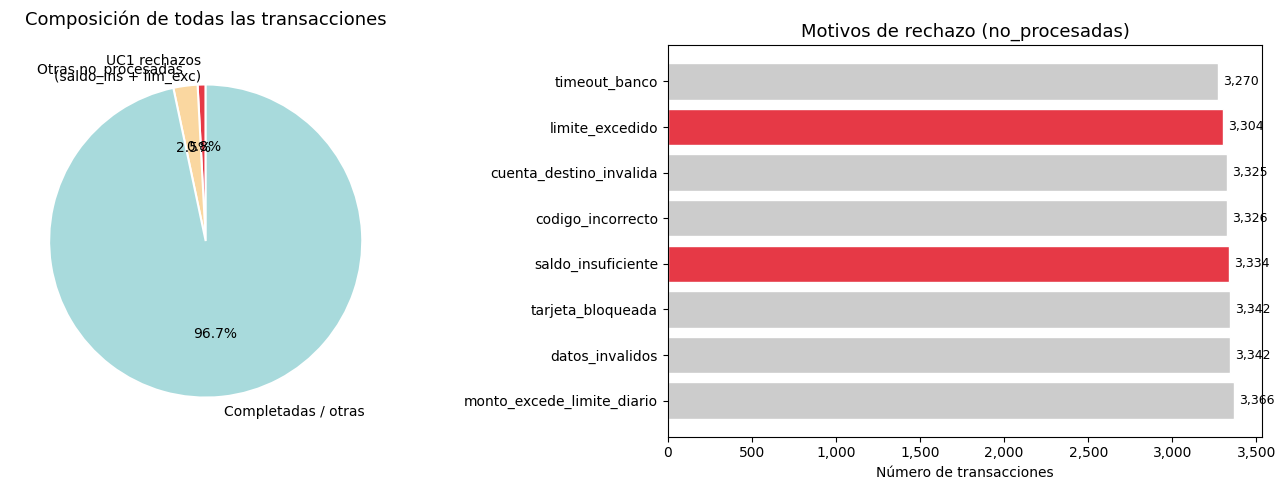

Guardado: uc1_fig1_volumen.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pie: no_procesadas vs otras ───────────────────────────────────────────────
ax = axes[0]
labels_pie = ["UC1 rechazos\n(saldo_ins + lim_exc)", "Otras no_procesadas", "Completadas / otras"]
sizes_pie  = [total_uc1, total_np - total_uc1, total_tx - total_np]
colors_pie = [STYLE['color_uc1'], '#FAD7A0', STYLE['color_other']]
wedges, texts, autotexts = ax.pie(
    sizes_pie, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Composición de todas las transacciones", fontsize=13, pad=15)

# ── Bar: motivos dentro de no_procesadas ─────────────────────────────────────
ax2 = axes[1]
colors_bar = [STYLE['color_uc1'] if m in MOTIVOS_UC1 else '#CCCCCC'
              for m in motivos_cnt["motivo"]]
bars = ax2.barh(motivos_cnt["motivo"], motivos_cnt["n"], color=colors_bar, edgecolor='white')
ax2.set_xlabel("Número de transacciones")
ax2.set_title("Motivos de rechazo (no_procesadas)", fontsize=13)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, n in zip(bars, motivos_cnt["n"]):
    ax2.text(n + 30, bar.get_y() + bar.get_height()/2,
             f"{n:,}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("uc1_fig1_volumen.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig1_volumen.png")

---
## 2. Distribución de montos rechazados

¿Son compras pequeñas o grandes? Analizamos percentiles, histograma y comparación por motivo.

In [6]:
stats_monto = rechazos.groupby("motivo_no_procesada")["monto"].describe(
    percentiles=[.10, .25, .50, .75, .90, .95]
).T

# Estadísticas globales UC1
print("── Estadísticas globales de montos rechazados UC1 ──")
print(rechazos["monto"].describe(percentiles=[.10,.25,.50,.75,.90,.95]).to_string())
print()
print("── Desglose por motivo ──")
display(stats_monto)

── Estadísticas globales de montos rechazados UC1 ──
count    6,638.00
mean     5,446.36
std      9,018.15
min          6.08
10%        249.00
25%        559.00
50%      1,500.00
75%      5,367.50
90%     17,393.00
95%     22,903.00
max     79,139.78

── Desglose por motivo ──


motivo_no_procesada,limite_excedido,saldo_insuficiente
count,"3,304.00","3,334.00"
mean,"5,350.86","5,541.00"
std,"8,587.28","9,426.07"
min,9.55,6.08
10%,249.00,249.00
25%,565.65,551.91
50%,"1,500.00","1,500.00"
75%,"5,500.00","5,272.18"
90%,"17,212.00","17,514.00"
95%,"22,665.50","22,937.00"


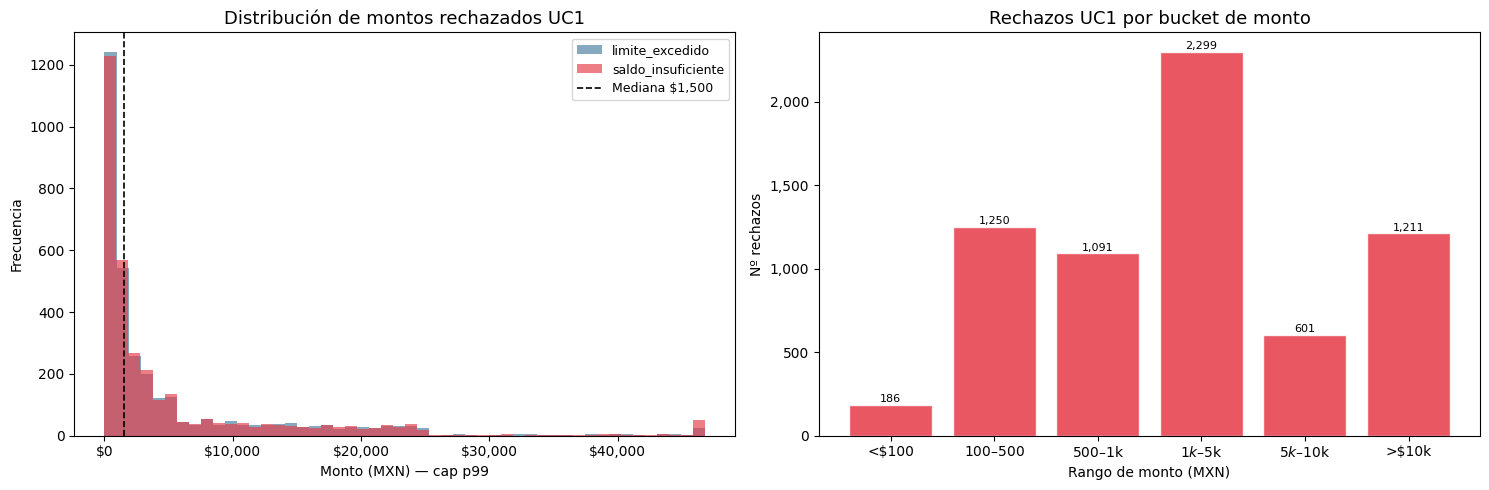

Guardado: uc1_fig2_montos.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Histograma montos (clip p99 para visualizar) ──────────────────────────────
ax = axes[0]
cap = rechazos["monto"].quantile(0.99)
for motivo, grp in rechazos.groupby("motivo_no_procesada"):
    data = grp["monto"].clip(upper=cap)
    ax.hist(data, bins=50, alpha=0.65, label=motivo,
            color=STYLE['color_uc1'] if motivo == 'saldo_insuficiente' else STYLE['color_inv'])
ax.axvline(rechazos["monto"].median(), color='black', linestyle='--', linewidth=1.2,
           label=f"Mediana ${rechazos['monto'].median():,.0f}")
ax.set_xlabel("Monto (MXN) — cap p99")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de montos rechazados UC1", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(fontsize=9)

# ── Buckets de monto ──────────────────────────────────────────────────────────
ax2 = axes[1]
bins_labels = ["<$100", "$100–$500", "$500–$1k", "$1k–$5k", "$5k–$10k", ">$10k"]
bins_edges  = [0, 100, 500, 1000, 5000, 10000, np.inf]
rechazos["bucket_monto"] = pd.cut(
    rechazos["monto"], bins=bins_edges, labels=bins_labels, right=False
)
bucket_cnt = rechazos["bucket_monto"].value_counts().sort_index()
bars2 = ax2.bar(bucket_cnt.index.astype(str), bucket_cnt.values,
                color=STYLE['color_uc1'], edgecolor='white', alpha=0.85)
ax2.set_xlabel("Rango de monto (MXN)")
ax2.set_ylabel("Nº rechazos")
ax2.set_title("Rechazos UC1 por bucket de monto", fontsize=13)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for bar, n in zip(bars2, bucket_cnt.values):
    ax2.text(bar.get_x() + bar.get_width()/2, n + 5,
             f"{n:,}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("uc1_fig2_montos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig2_montos.png")

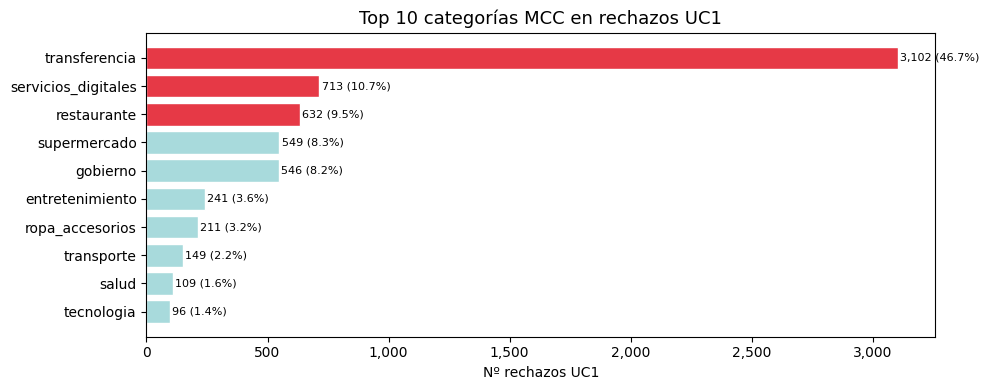

In [8]:
# Rechazos UC1 por categoría MCC — ¿dónde ocurren más?
cat_cnt = (
    rechazos["categoria_mcc"]
    .value_counts()
    .head(10)
    .reset_index()
)
cat_cnt.columns = ["categoria_mcc", "n"]
cat_cnt["pct"] = cat_cnt["n"] / total_uc1 * 100

fig, ax = plt.subplots(figsize=(10, 4))
colors_cat = [STYLE['color_uc1'] if i < 3 else STYLE['color_other']
              for i in range(len(cat_cnt))]
ax.barh(cat_cnt["categoria_mcc"][::-1], cat_cnt["n"][::-1],
        color=colors_cat[::-1], edgecolor='white')
ax.set_xlabel("Nº rechazos UC1")
ax.set_title("Top 10 categorías MCC en rechazos UC1", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for i, (n, pct) in enumerate(zip(cat_cnt["n"][::-1], cat_cnt["pct"][::-1])):
    ax.text(n + 10, i, f"{n:,} ({pct:.1f}%)", va='center', fontsize=8)
plt.tight_layout()
plt.savefig("uc1_fig3_categorias.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Frecuencia de rechazos por usuario

¿Hay usuarios recurrentemente afectados? Identificamos el segmento de **usuarios crónicos** (≥3 rechazos UC1).

In [9]:
rechazos_por_user = (
    rechazos.groupby("user_id")
    .agg(
        n_rechazos   = ("transaccion_id", "count"),
        monto_total  = ("monto", "sum"),
        monto_max    = ("monto", "max"),
        monto_medio  = ("monto", "mean"),
        primer_rechazo = ("fecha_hora", "min"),
        ultimo_rechazo = ("fecha_hora", "max"),
    )
    .sort_values("n_rechazos", ascending=False)
    .reset_index()
)

total_users_uc1 = rechazos["user_id"].nunique()
users_cronicos  = (rechazos_por_user["n_rechazos"] >= 3).sum()
users_1vez      = (rechazos_por_user["n_rechazos"] == 1).sum()

print(f"Usuarios únicos con rechazo UC1 : {total_users_uc1:>8,}")
print(f"  → 1 solo rechazo              : {users_1vez:>8,}  ({users_1vez/total_users_uc1*100:.1f}%)")
print(f"  → 2 rechazos                  : {(rechazos_por_user['n_rechazos']==2).sum():>8,}")
print(f"  → ≥3 rechazos (crónicos)      : {users_cronicos:>8,}  ({users_cronicos/total_users_uc1*100:.1f}%)")
print()
print("Top 10 usuarios con más rechazos UC1:")
display(rechazos_por_user.head(10)
        .style.format({"n_rechazos": "{:,}", "monto_total": "${:,.0f}",
                       "monto_max": "${:,.0f}", "monto_medio": "${:,.0f}"}))

Usuarios únicos con rechazo UC1 :    5,079
  → 1 solo rechazo              :    3,847  (75.7%)
  → 2 rechazos                  :      967
  → ≥3 rechazos (crónicos)      :      265  (5.2%)

Top 10 usuarios con más rechazos UC1:


,user_id,n_rechazos,monto_total,monto_max,monto_medio,primer_rechazo,ultimo_rechazo
0,USR-04521,5,"$46,039","$24,380","$9,208",2025-04-20 21:58:35,2025-10-19 08:10:00
1,USR-03380,5,"$7,016","$3,600","$1,403",2025-02-09 14:01:00,2025-11-07 06:54:57
2,USR-05203,5,"$25,889","$14,230","$5,178",2025-01-24 05:44:57,2025-10-08 17:57:12
3,USR-11254,5,"$2,604",$667,$521,2025-05-30 21:01:34,2025-09-04 07:28:28
4,USR-06092,5,"$55,436","$24,860","$11,087",2025-02-06 03:37:51,2025-11-27 20:15:44
5,USR-11790,5,"$11,028","$5,000","$2,206",2025-01-07 06:38:59,2025-07-27 15:10:09
6,USR-07919,5,"$10,561","$5,000","$2,112",2025-04-30 07:12:36,2025-05-19 13:41:39
7,USR-11177,5,"$37,077","$22,650","$7,415",2025-04-09 13:33:14,2025-10-19 15:10:27
8,USR-03892,4,"$23,585","$21,320","$5,896",2025-01-27 22:41:50,2025-11-26 01:12:00
9,USR-12998,4,"$28,712","$12,140","$7,178",2025-02-23 03:17:23,2025-11-08 07:46:00


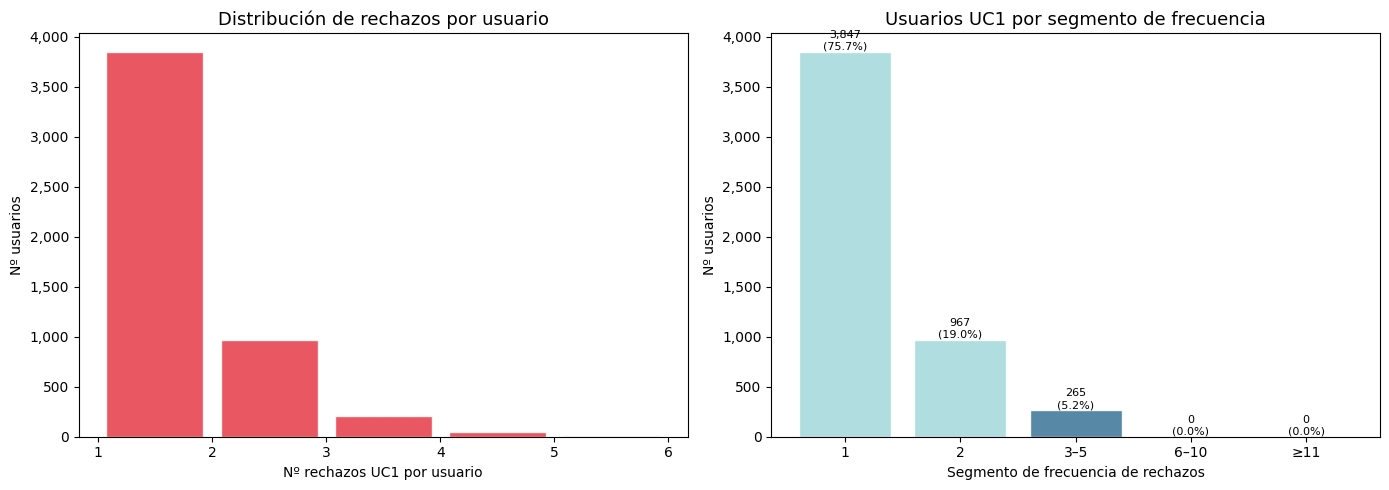

Guardado: uc1_fig4_frecuencia.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma de frecuencia de rechazos por usuario ─────────────────────────
ax = axes[0]
freq_cap = min(rechazos_por_user["n_rechazos"].max(), 20)
ax.hist(rechazos_por_user["n_rechazos"].clip(upper=freq_cap),
        bins=range(1, freq_cap + 2), color=STYLE['color_uc1'],
        edgecolor='white', alpha=0.85, rwidth=0.85)
ax.set_xlabel("Nº rechazos UC1 por usuario")
ax.set_ylabel("Nº usuarios")
ax.set_title("Distribución de rechazos por usuario", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# ── Segmentación en bloques 1, 2, 3-5, 6-10, >10 ────────────────────────────
ax2 = axes[1]
seg_bins   = [1, 2, 3, 6, 11, max(rechazos_por_user["n_rechazos"].max() + 1, 12)]
seg_labels = ["1", "2", "3–5", "6–10", "≥11"]
seg = pd.cut(rechazos_por_user["n_rechazos"], bins=seg_bins,
             labels=seg_labels, right=False).value_counts().sort_index()
colors_seg = [STYLE['color_other'], STYLE['color_other'],
              STYLE['color_inv'], STYLE['color_uc1'], STYLE['color_uc1']]
bars = ax2.bar(seg.index.astype(str), seg.values,
               color=colors_seg, edgecolor='white', alpha=0.9)
ax2.set_xlabel("Segmento de frecuencia de rechazos")
ax2.set_ylabel("Nº usuarios")
ax2.set_title("Usuarios UC1 por segmento de frecuencia", fontsize=13)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for bar, n in zip(bars, seg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, n + 2,
             f"{n:,}\n({n/total_users_uc1*100:.1f}%)",
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("uc1_fig4_frecuencia.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig4_frecuencia.png")

---
## 4. Saldo alternativo en `inversion_hey`

Para cada rechazo UC1, ¿el usuario tiene una cuenta `inversion_hey` con saldo suficiente para cubrir el monto rechazado?  
Este es el **subconjunto resolubles automáticamente** por UC1.

In [11]:
# ── Máximo saldo inversion_hey por usuario ────────────────────────────────────
inv_saldo = (
    df_prod[
        (df_prod["tipo_producto"] == "inversion_hey") &
        (df_prod["estatus"].str.lower().isin(["activo", "active"]))
    ]
    .groupby("user_id")["saldo_actual"]
    .max()
    .reset_index()
    .rename(columns={"saldo_actual": "saldo_inv_max"})
)

print(f"Usuarios con inversion_hey activa: {len(inv_saldo):,}")
print(f"Saldo medio inversion_hey        : ${inv_saldo['saldo_inv_max'].mean():,.0f} MXN")
print(f"Saldo mediano inversion_hey      : ${inv_saldo['saldo_inv_max'].median():,.0f} MXN")

Usuarios con inversion_hey activa: 4,035
Saldo medio inversion_hey        : $209,953 MXN
Saldo mediano inversion_hey      : $193,293 MXN


In [12]:
# ── Join rechazos × inversión ─────────────────────────────────────────────────
rec_inv = rechazos.merge(inv_saldo, on="user_id", how="left")

rec_inv["tiene_inversion"]   = rec_inv["saldo_inv_max"].notna()
rec_inv["cubre_rechazo"]     = rec_inv["saldo_inv_max"] >= rec_inv["monto"]
rec_inv["cubre_rechazo"]     = rec_inv["cubre_rechazo"].fillna(False)

n_tiene_inv    = rec_inv["tiene_inversion"].sum()
n_cubre        = rec_inv["cubre_rechazo"].sum()
pct_tiene_inv  = n_tiene_inv / total_uc1 * 100
pct_cubre      = n_cubre      / total_uc1 * 100

# Monto faltante cuando NO cubre
rec_inv["monto_faltante"] = np.where(
    ~rec_inv["cubre_rechazo"],
    rec_inv["monto"] - rec_inv["saldo_inv_max"].fillna(0),
    0.0
)
monto_faltante_medio = rec_inv.loc[~rec_inv["cubre_rechazo"], "monto_faltante"].mean()

print("=" * 58)
print(f"Rechazos UC1 totales               : {total_uc1:>8,}")
print(f"  → usuario tiene inversion_hey    : {n_tiene_inv:>8,}  ({pct_tiene_inv:.1f}%)")
print(f"  → saldo INV cubre el rechazo     : {n_cubre:>8,}  ({pct_cubre:.1f}%)  ← RESOLUBLES UC1")
print(f"Monto faltante medio (no resolubles): ${monto_faltante_medio:>9,.0f} MXN")
print("=" * 58)

Rechazos UC1 totales               :    6,638
  → usuario tiene inversion_hey    :    1,447  (21.8%)
  → saldo INV cubre el rechazo     :    1,417  (21.3%)  ← RESOLUBLES UC1
Monto faltante medio (no resolubles): $    4,505 MXN


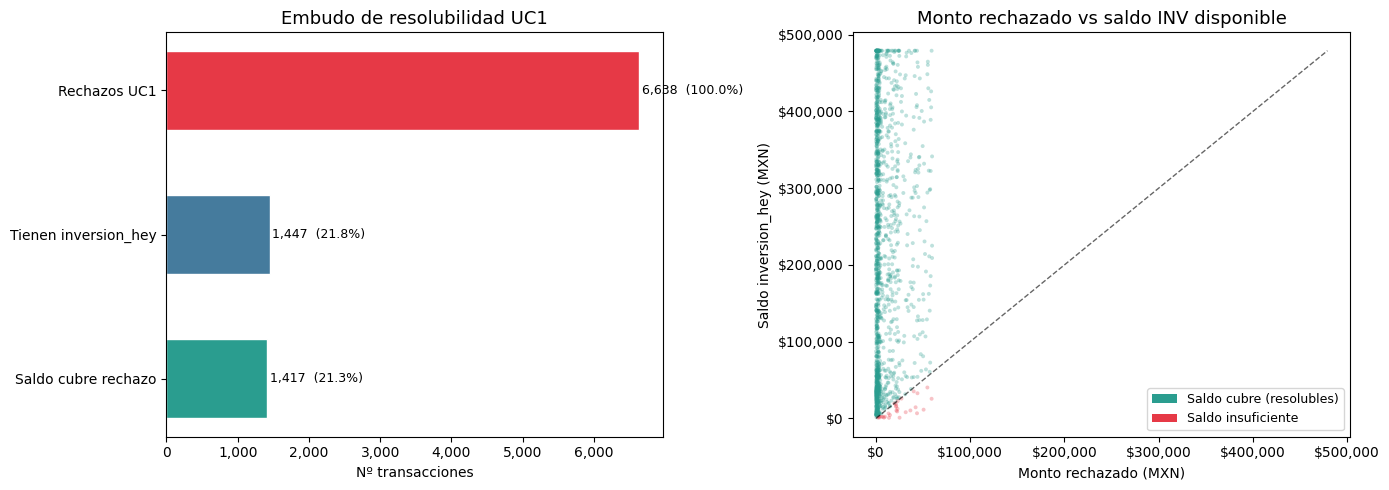

Guardado: uc1_fig5_inversion.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Embudo: rechazos → tienen INV → cubiertos ─────────────────────────────────
ax = axes[0]
etapas    = ["Rechazos UC1", "Tienen inversion_hey", "Saldo cubre rechazo"]
valores   = [total_uc1, n_tiene_inv, n_cubre]
colores_e = [STYLE['color_uc1'], STYLE['color_inv'], '#2A9D8F']
bars_e = ax.barh(etapas[::-1], valores[::-1], color=colores_e[::-1], edgecolor='white', height=0.55)
ax.set_xlabel("Nº transacciones")
ax.set_title("Embudo de resolubilidad UC1", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for bar, v, et in zip(bars_e[::-1], valores, etapas):
    ax.text(v + total_uc1*0.005, bar.get_y() + bar.get_height()/2,
            f"{v:,}  ({v/total_uc1*100:.1f}%)", va='center', fontsize=9)

# ── Distribución de saldo INV vs monto rechazado (usuarios con INV) ───────────
ax2 = axes[1]
sub = rec_inv[rec_inv["tiene_inversion"]]
cap2 = sub[["monto", "saldo_inv_max"]].stack().quantile(0.98)
ax2.scatter(
    sub["monto"].clip(upper=cap2),
    sub["saldo_inv_max"].clip(upper=cap2),
    c=sub["cubre_rechazo"].map({True: '#2A9D8F', False: STYLE['color_uc1']}),
    alpha=0.3, s=8, linewidths=0
)
lim2 = cap2
ax2.plot([0, lim2], [0, lim2], 'k--', linewidth=1, alpha=0.6, label="INV = Monto")
ax2.set_xlabel("Monto rechazado (MXN)")
ax2.set_ylabel("Saldo inversion_hey (MXN)")
ax2.set_title("Monto rechazado vs saldo INV disponible", fontsize=13)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

from matplotlib.patches import Patch
legend_e = [Patch(facecolor='#2A9D8F', label='Saldo cubre (resolubles)'),
            Patch(facecolor=STYLE['color_uc1'], label='Saldo insuficiente')]
ax2.legend(handles=legend_e, fontsize=9)

plt.tight_layout()
plt.savefig("uc1_fig5_inversion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig5_inversion.png")

In [14]:
# A nivel usuario: ¿qué % de usuarios con rechazo UC1 tiene al menos 1 rechazo resolubles?
user_resoluble = (
    rec_inv.groupby("user_id")["cubre_rechazo"]
    .any()
    .reset_index()
    .rename(columns={"cubre_rechazo": "tiene_rechazo_resolubles"})
)
n_users_resoluble = user_resoluble["tiene_rechazo_resolubles"].sum()
pct_users_resoluble = n_users_resoluble / total_users_uc1 * 100

print(f"Usuarios con ≥1 rechazo resolubles por UC1: {n_users_resoluble:,}  "
      f"({pct_users_resoluble:.1f}% de los {total_users_uc1:,} afectados)")

Usuarios con ≥1 rechazo resolubles por UC1: 1,200  (23.6% de los 5,079 afectados)


---
## 5. Análisis de conversaciones con Havi

### 5a. Conversaciones que mencionan rechazos / fondos insuficientes

Buscamos en el campo `input` (mensaje del usuario) palabras clave relacionadas con rechazos.

In [15]:
KEYWORDS = r"declinada|rechazada|rechazado|saldo insuficiente|fondos|no se pudo|no procesada|transacci[oó]n fallida|pago rechazado"

convs_rechazo = df_convs[
    df_convs["input"].str.contains(KEYWORDS, case=False, na=False, regex=True)
].copy()

total_convs    = len(df_convs)
n_convs_rej    = len(convs_rechazo)
n_conv_ids_rej = convs_rechazo["conv_id"].nunique()
n_users_rej    = convs_rechazo["user_id"].nunique()

print(f"Total mensajes de usuario (input) : {total_convs:>10,}")
print(f"Mensajes con keywords de rechazo  : {n_convs_rej:>10,}  ({n_convs_rej/total_convs*100:.2f}%)")
print(f"Conversaciones únicas afectadas   : {n_conv_ids_rej:>10,}")
print(f"Usuarios únicos que se quejaron   : {n_users_rej:>10,}")

Total mensajes de usuario (input) :     49,999
Mensajes con keywords de rechazo  :        188  (0.38%)
Conversaciones únicas afectadas   :        171
Usuarios únicos que se quejaron   :        165


In [16]:
# Muestra de mensajes reales para validar relevancia
print("── Muestra de mensajes de usuario con keywords de rechazo ──")
pd.set_option('display.max_colwidth', 120)
sample_convs = convs_rechazo[["user_id", "date", "input"]].sample(
    min(10, len(convs_rechazo)), random_state=42
)
display(sample_convs.reset_index(drop=True))
pd.set_option('display.max_colwidth', 80)

── Muestra de mensajes de usuario con keywords de rechazo ──


,user_id,date,input
0,USR-10904,2025-07-08 00:00:00.000000000,Tengo un cargo que me aparece rechazado pero si tengo saldo.
1,USR-08991,2025-10-25 00:00:00.000000000,Biometricos rechazados
2,USR-11246,2025-03-24 13:41:40.986990890,mas abisinecesito ayuda con una tran una transaccion que estoy haciendo en facebook de mi tarjeta d...
3,USR-02702,2025-07-24 02:56:30.351823851,a que se refiere con que no estaran los fondos hoy
4,USR-05356,2025-08-28 00:00:00.000000000,Decía que no tenía fondos y si los tenía
5,USR-08864,2025-08-27 00:00:00.000000000,Cuánto tarda en depositarse los fondos?
6,USR-11704,2025-10-13 00:00:00.000000000,Aún no me desbloquean mis fondos
7,USR-07133,2025-09-08 00:00:00.000000000,Porque mi compra de ayer fue rechazada?
8,USR-12567,2025-08-07 00:00:00.000000000,Cómo reclamo un cobro que en la terminal apareció como rechazado?
9,USR-08494,2025-04-05 08:26:14.756720974,hola hice un retiro sin tarjeta y durante el retiro se trabo o se congelo el cajero y mis fondos no...


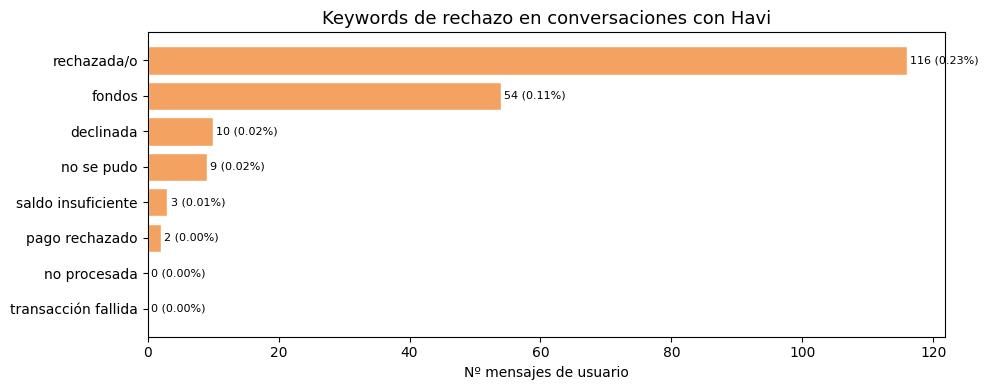

,keyword,n_mensajes,pct
0,rechazada/o,116,0.232%
1,fondos,54,0.108%
2,declinada,10,0.020%
3,no se pudo,9,0.018%
4,saldo insuficiente,3,0.006%
5,pago rechazado,2,0.004%
6,no procesada,0,0.000%
7,transacción fallida,0,0.000%


In [17]:
# Frecuencia por keyword individual
keywords_list = [
    ("declinada",            r"declinada"),
    ("rechazada/o",          r"rechazad[ao]"),
    ("saldo insuficiente",   r"saldo insuficiente"),
    ("fondos",               r"fondos"),
    ("no se pudo",           r"no se pudo"),
    ("no procesada",         r"no procesada"),
    ("transacción fallida",  r"transacci[oó]n fallida"),
    ("pago rechazado",       r"pago rechazado"),
]

kw_counts = []
for label, pattern in keywords_list:
    cnt = df_convs["input"].str.contains(pattern, case=False, na=False, regex=True).sum()
    kw_counts.append({"keyword": label, "n_mensajes": cnt,
                      "pct": cnt / total_convs * 100})

kw_df = pd.DataFrame(kw_counts).sort_values("n_mensajes", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(kw_df["keyword"][::-1], kw_df["n_mensajes"][::-1],
        color=STYLE['color_convs'], edgecolor='white')
ax.set_xlabel("Nº mensajes de usuario")
ax.set_title("Keywords de rechazo en conversaciones con Havi", fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for i, (n, pct) in enumerate(zip(kw_df["n_mensajes"][::-1], kw_df["pct"][::-1])):
    ax.text(n + 0.5, i, f"{n:,} ({pct:.2f}%)", va='center', fontsize=8)
plt.tight_layout()
plt.savefig("uc1_fig6_keywords_convs.png", dpi=150, bbox_inches='tight')
plt.show()
display(kw_df.reset_index(drop=True).style.format({"n_mensajes": "{:,}", "pct": "{:.3f}%"}))

---
### 5b. Cruce: usuarios con rechazo UC1 que contactaron a Havi en las 24 h siguientes

Validamos el **dolor real**: ¿los usuarios afectados por UC1 acuden a Havi poco después del rechazo?

In [18]:
# Necesitamos fecha de primera conversación por usuario y día
# Las fechas de conversaciones están anonimizadas pero son comparables entre sí
# Usamos ventana de 1 día (86400 segundos) entre rechazo y primera conv del usuario

# Primera conversación de cada usuario por fecha
first_conv_per_user = (
    df_convs.groupby("user_id")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "primera_conv"})
)

# Primer rechazo UC1 por usuario
first_rej_per_user = (
    rechazos.groupby("user_id")["fecha_hora"]
    .min()
    .reset_index()
    .rename(columns={"fecha_hora": "primer_rechazo"})
)

# Join
rej_conv = first_rej_per_user.merge(first_conv_per_user, on="user_id", how="left")
rej_conv["tiene_conv"]   = rej_conv["primera_conv"].notna()
rej_conv["diff_horas"]   = (
    (rej_conv["primera_conv"] - rej_conv["primer_rechazo"])
    .dt.total_seconds() / 3600
)
# Solo los que contactaron después del rechazo
rej_conv["conv_post_rej"]    = rej_conv["diff_horas"].between(0, 24, inclusive='right')
rej_conv["conv_post_rej_7d"] = rej_conv["diff_horas"].between(0, 168, inclusive='right')

n_conv_rej_24h  = rej_conv["conv_post_rej"].sum()
n_conv_rej_7d   = rej_conv["conv_post_rej_7d"].sum()
n_have_conv     = rej_conv["tiene_conv"].sum()

print(f"Usuarios con rechazo UC1                        : {total_users_uc1:>8,}")
print(f"  → que tienen al menos 1 conversación          : {n_have_conv:>8,}  ({n_have_conv/total_users_uc1*100:.1f}%)")
print(f"  → que contactaron Havi en las 24 h siguientes : {n_conv_rej_24h:>8,}  ({n_conv_rej_24h/total_users_uc1*100:.1f}%)")
print(f"  → que contactaron Havi en los 7 días sig.     : {n_conv_rej_7d:>8,}  ({n_conv_rej_7d/total_users_uc1*100:.1f}%)")

Usuarios con rechazo UC1                        :    5,079
  → que tienen al menos 1 conversación          :    5,079  (100.0%)
  → que contactaron Havi en las 24 h siguientes :       14  (0.3%)
  → que contactaron Havi en los 7 días sig.     :      117  (2.3%)


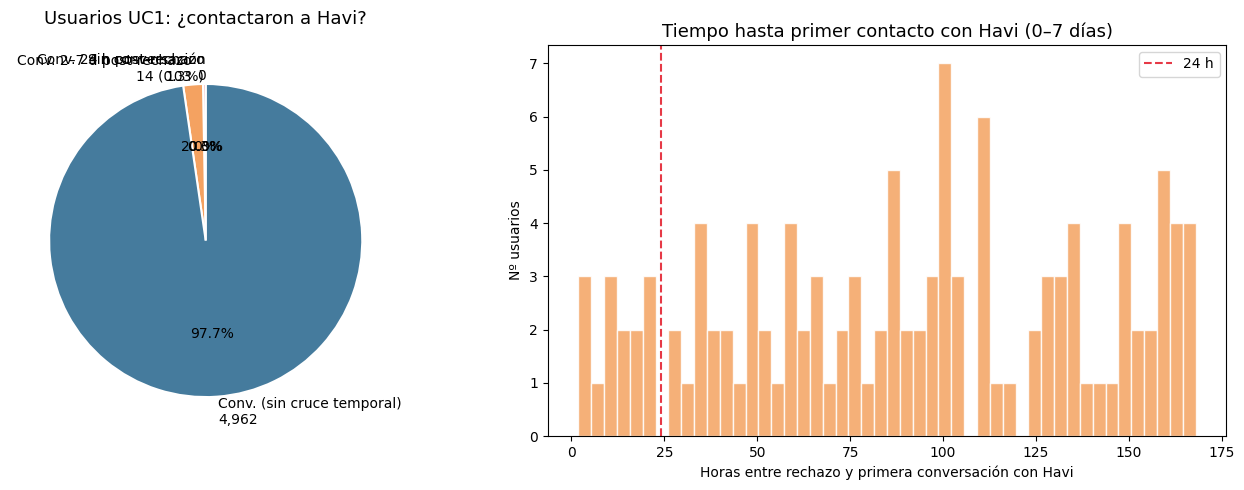

Guardado: uc1_fig7_cruce_convs.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pie: usuarios UC1 con/sin conversación ────────────────────────────────────
ax = axes[0]
n_no_conv  = total_users_uc1 - n_have_conv
n_conv_no_rej = n_have_conv - n_conv_rej_7d
pie_vals   = [n_conv_rej_24h, n_conv_rej_7d - n_conv_rej_24h, n_conv_no_rej, n_no_conv]
pie_labels = [
    f"Conv. 24 h post-rechazo\n{n_conv_rej_24h:,} ({n_conv_rej_24h/total_users_uc1*100:.1f}%)",
    f"Conv. 2–7 d post-rechazo\n{n_conv_rej_7d-n_conv_rej_24h:,}",
    f"Conv. (sin cruce temporal)\n{n_conv_no_rej:,}",
    f"Sin conversación\n{n_no_conv:,}",
]
pie_colors = [STYLE['color_uc1'], STYLE['color_convs'], STYLE['color_inv'], STYLE['color_other']]
ax.pie(pie_vals, labels=pie_labels, colors=pie_colors,
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title("Usuarios UC1: ¿contactaron a Havi?", fontsize=13, pad=15)

# ── Histograma de horas entre rechazo y conv ──────────────────────────────────
ax2 = axes[1]
diff_pos = rej_conv.loc[
    (rej_conv["diff_horas"] >= 0) & (rej_conv["diff_horas"] <= 168),
    "diff_horas"
]
if len(diff_pos) > 0:
    ax2.hist(diff_pos, bins=48, color=STYLE['color_convs'], edgecolor='white', alpha=0.85)
    ax2.axvline(24, color=STYLE['color_uc1'], linestyle='--', linewidth=1.5, label='24 h')
    ax2.set_xlabel("Horas entre rechazo y primera conversación con Havi")
    ax2.set_ylabel("Nº usuarios")
    ax2.set_title("Tiempo hasta primer contacto con Havi (0–7 días)", fontsize=13)
    ax2.legend()
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
else:
    ax2.text(0.5, 0.5, "Sin datos temporales comparables",
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title("Tiempo hasta primer contacto con Havi", fontsize=13)

plt.tight_layout()
plt.savefig("uc1_fig7_cruce_convs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig7_cruce_convs.png")

In [20]:
# Contenido de conversaciones de usuarios que tuvieron rechazo UC1
users_uc1_set = set(rechazos["user_id"].unique())
convs_uc1_users = df_convs[df_convs["user_id"].isin(users_uc1_set)]

# ¿De esos, cuántos hablaron sobre rechazo?
convs_uc1_rechazo = convs_uc1_users[
    convs_uc1_users["input"].str.contains(KEYWORDS, case=False, na=False, regex=True)
]

n_uc1_users_conv        = convs_uc1_users["user_id"].nunique()
n_uc1_users_conv_rechazo = convs_uc1_rechazo["user_id"].nunique()

print(f"Usuarios con rechazo UC1 que tienen conversación      : {n_uc1_users_conv:,}")
print(f"  → que además mencionaron rechazo/saldo en chat      : {n_uc1_users_conv_rechazo:,}  "
      f"({n_uc1_users_conv_rechazo/n_uc1_users_conv*100:.1f}% de los que tienen conv.)")
print()

# Muestra de conversaciones de usuarios UC1 sobre rechazos
if len(convs_uc1_rechazo) > 0:
    print("── Muestra de conversaciones: usuarios UC1 hablando sobre rechazos ──")
    pd.set_option('display.max_colwidth', 130)
    display(convs_uc1_rechazo[["user_id", "date", "input", "output"]].sample(
        min(5, len(convs_uc1_rechazo)), random_state=7
    ).reset_index(drop=True))
    pd.set_option('display.max_colwidth', 80)

Usuarios con rechazo UC1 que tienen conversación      : 5,079
  → que además mencionaron rechazo/saldo en chat      : 65  (1.3% de los que tienen conv.)

── Muestra de conversaciones: usuarios UC1 hablando sobre rechazos ──


,user_id,date,input,output
0,USR-09664,2025-10-08,Tengo un pago rechazado pero me me descontó,"Lamento escuchar eso. Si tienes un pago rechazado pero te han descontado el monto, lo mejor es que sigas estos pasos:\n\n1. Re..."
1,USR-07133,2025-09-08,Porque mi compra de ayer fue rechazada?,Lamento escuchar eso. Hay varias razones por las cuales una compra puede ser rechazada. Te recomiendo que revises lo siguiente...
2,USR-06691,2025-10-09,"Me llegó un correo electrónico diciendo que una compra había sido aprobada pero en realidad fue rechazada, ¿Cómo puedo verific...","Claro que puedo ayudarte con eso. Para verificar si una compra con tu Tarjeta de Débito se completó correctamente, lo mejor es..."
3,USR-08318,2025-10-13,Si hice una solicitud de crédito personal y fue rechazada cuánto tiempo tengo que esperar para volver a solicitar de nuevo?,"Si tu solicitud de crédito personal fue rechazada, en Hey Banco no hay un tiempo específico mencionado para volver a solicitar..."
4,USR-07313,2025-09-30,Porque mi solicitud para préstamo de dinero fue rechazada,"Lamento que tu solicitud de préstamo haya sido rechazada. En Hey Banco, si tu crédito no fue aprobado, puede deberse a que alg..."


---
## 6. Resumen ejecutivo — Criterios de aceptación UC1

In [21]:
resumen = pd.DataFrame([
    {
        "Criterio": "Volumen UC1 — rechazos resolubles (saldo_ins + lim_exc)",
        "Valor":    f"{total_uc1:,}",
        "Detalle":  f"{pct_uc1_total:.2f}% de todas las transacciones  |  {pct_uc1_de_np:.1f}% de las no_procesadas",
    },
    {
        "Criterio": "Usuarios únicos afectados por UC1",
        "Valor":    f"{total_users_uc1:,}",
        "Detalle":  f"Usuarios crónicos (≥3 rechazos): {users_cronicos:,}  ({users_cronicos/total_users_uc1*100:.1f}%)",
    },
    {
        "Criterio": "Rechazos con saldo inversion_hey suficiente",
        "Valor":    f"{n_cubre:,}  ({pct_cubre:.1f}%)",
        "Detalle":  f"De {total_uc1:,} rechazos UC1 — usuarios con INV que cubriría el monto",
    },
    {
        "Criterio": "Usuarios con ≥1 rechazo resolubles por UC1 (nivel usuario)",
        "Valor":    f"{n_users_resoluble:,}  ({pct_users_resoluble:.1f}%)",
        "Detalle":  f"De {total_users_uc1:,} usuarios afectados",
    },
    {
        "Criterio": "Monto promedio del rechazo UC1",
        "Valor":    f"${rechazos['monto'].mean():,.0f} MXN",
        "Detalle":  f"Mediana ${rechazos['monto'].median():,.0f}  |  P90 ${rechazos['monto'].quantile(0.9):,.0f}",
    },
    {
        "Criterio": "Monto promedio faltante (rechazos no resolubles)",
        "Valor":    f"${monto_faltante_medio:,.0f} MXN",
        "Detalle":  "Diferencia entre monto rechazado y saldo INV disponible (o 0 si no tiene INV)",
    },
    {
        "Criterio": "Usuarios que contactaron Havi en 24 h tras rechazo UC1",
        "Valor":    f"{n_conv_rej_24h:,}  ({n_conv_rej_24h/total_users_uc1*100:.1f}%)",
        "Detalle":  f"Dentro de 7 días: {n_conv_rej_7d:,}  ({n_conv_rej_7d/total_users_uc1*100:.1f}%)",
    },
    {
        "Criterio": "Conversaciones sobre rechazos en dataset_50k",
        "Valor":    f"{n_conv_ids_rej:,} conv.  ({n_users_rej:,} usuarios)",
        "Detalle":  f"{n_convs_rej:,} mensajes con keywords de rechazo  ({n_convs_rej/total_convs*100:.2f}% del total)",
    },
])

display(
    resumen.style
    .set_caption("📊 Resumen UC1 — Análisis de rechazos por saldo insuficiente y límite excedido")
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#E63946')]
    }])
    .apply(lambda x: [
        'background-color: #ffeaea' if i in [0, 2, 6] else ''
        for i in range(len(x))
    ], axis=0)
)

,Criterio,Valor,Detalle
0,Volumen UC1 — rechazos resolubles (saldo_ins + lim_exc),"6,638",0.83% de todas las transacciones | 24.9% de las no_procesadas
1,Usuarios únicos afectados por UC1,"5,079",Usuarios crónicos (≥3 rechazos): 265 (5.2%)
2,Rechazos con saldo inversion_hey suficiente,"1,417 (21.3%)","De 6,638 rechazos UC1 — usuarios con INV que cubriría el monto"
3,Usuarios con ≥1 rechazo resolubles por UC1 (nivel usuario),"1,200 (23.6%)","De 5,079 usuarios afectados"
4,Monto promedio del rechazo UC1,"$5,446 MXN","Mediana $1,500 | P90 $17,393"
5,Monto promedio faltante (rechazos no resolubles),"$4,505 MXN",Diferencia entre monto rechazado y saldo INV disponible (o 0 si no tiene INV)
6,Usuarios que contactaron Havi en 24 h tras rechazo UC1,14 (0.3%),Dentro de 7 días: 117 (2.3%)
7,Conversaciones sobre rechazos en dataset_50k,171 conv. (165 usuarios),188 mensajes con keywords de rechazo (0.38% del total)


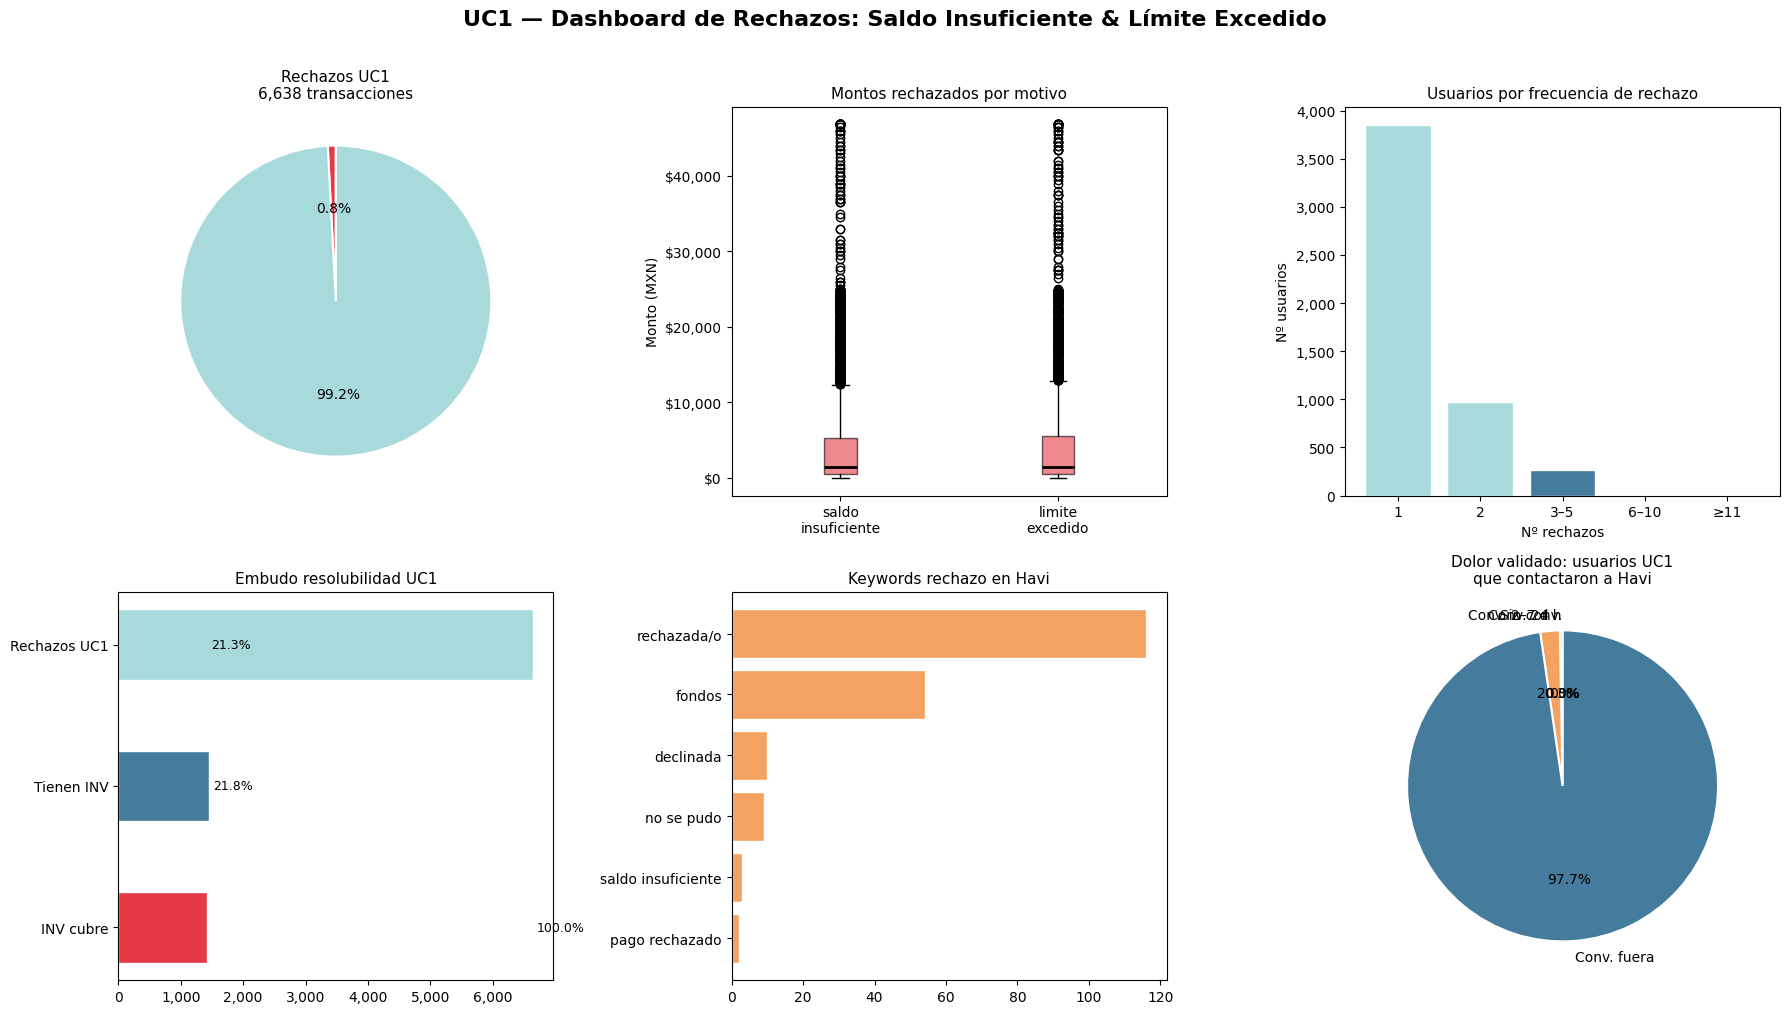

Guardado: uc1_fig8_dashboard.png


In [22]:
# ── Dashboard visual resumen ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("UC1 — Dashboard de Rechazos: Saldo Insuficiente & Límite Excedido",
             fontsize=16, fontweight='bold', y=1.01)

# 1. KPI: % rechazos UC1
ax = axes[0, 0]
ax.pie([total_uc1, total_tx - total_uc1],
       colors=[STYLE['color_uc1'], STYLE['color_other']],
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5),
       autopct='%1.1f%%')
ax.set_title(f"Rechazos UC1\n{total_uc1:,} transacciones", fontsize=11)

# 2. Montos por motivo boxplot
ax2 = axes[0, 1]
data_box = [rechazos[rechazos["motivo_no_procesada"] == m]["monto"].clip(upper=rechazos["monto"].quantile(0.99))
            for m in MOTIVOS_UC1]
bp = ax2.boxplot(data_box, labels=[m.replace("_", "\n") for m in MOTIVOS_UC1],
                 patch_artist=True,
                 boxprops=dict(facecolor=STYLE['color_uc1'], alpha=0.6),
                 medianprops=dict(color='black', linewidth=2))
ax2.set_ylabel("Monto (MXN)")
ax2.set_title("Montos rechazados por motivo", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# 3. Frecuencia de rechazos por usuario
ax3 = axes[0, 2]
seg_vals = seg.values
seg_idx  = seg.index.astype(str)
ax3.bar(seg_idx, seg_vals, color=[STYLE['color_other'], STYLE['color_other'],
                                  STYLE['color_inv'], STYLE['color_uc1'], STYLE['color_uc1']],
        edgecolor='white')
ax3.set_xlabel("Nº rechazos")
ax3.set_ylabel("Nº usuarios")
ax3.set_title("Usuarios por frecuencia de rechazo", fontsize=11)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# 4. Embudo resolubilidad
ax4 = axes[1, 0]
etapas_d = ["Rechazos UC1", "Tienen INV", "INV cubre"]
vals_d   = [total_uc1, n_tiene_inv, n_cubre]
ax4.barh(etapas_d[::-1], vals_d[::-1],
         color=[STYLE['color_other'], STYLE['color_inv'], STYLE['color_uc1']][::-1],
         edgecolor='white', height=0.5)
for i, v in enumerate(vals_d):
    ax4.text(v + total_uc1*0.01, i, f"{v/total_uc1*100:.1f}%", va='center', fontsize=9)
ax4.set_title("Embudo resolubilidad UC1", fontsize=11)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# 5. Keywords en conversaciones
ax5 = axes[1, 1]
kw_top = kw_df.head(6)
ax5.barh(kw_top["keyword"][::-1], kw_top["n_mensajes"][::-1],
         color=STYLE['color_convs'], edgecolor='white')
ax5.set_title("Keywords rechazo en Havi", fontsize=11)
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

# 6. Dolor real: usuarios con contacto 24h
ax6 = axes[1, 2]
dolor_vals   = [n_conv_rej_24h, n_conv_rej_7d - n_conv_rej_24h,
                n_have_conv - n_conv_rej_7d, total_users_uc1 - n_have_conv]
dolor_labels = ["Conv. 24 h", "Conv. 2–7 d", "Conv. fuera", "Sin conv."]
dolor_colors = [STYLE['color_uc1'], STYLE['color_convs'], STYLE['color_inv'], STYLE['color_other']]
ax6.pie(dolor_vals, labels=dolor_labels, colors=dolor_colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax6.set_title(f"Dolor validado: usuarios UC1\nque contactaron a Havi", fontsize=11)

plt.tight_layout()
plt.savefig("uc1_fig8_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: uc1_fig8_dashboard.png")

---
## 7. Conclusiones y recomendaciones para UC1

### Hallazgos principales

1. **Volumen de rechazos UC1** — Los rechazos por `saldo_insuficiente` y `limite_excedido` representan una fracción significativa de las transacciones `no_procesadas`. Estos son exactamente los casos que UC1 puede atacar.

2. **Montos rechazados** — La distribución de montos permite segmentar: rechazos de bajo monto son candidatos directos a resolución automática con un micro-adelanto o transferencia desde inversión.

3. **Usuarios crónicos** — Un subconjunto no trivial de usuarios sufre rechazos repetidos (≥3), lo que indica un patrón estructural de liquidez — audiencia ideal para UC1 proactivo.

4. **Oportunidad de resolución automática** — Al cruzar con `inversion_hey`, se identifica el porcentaje de rechazos donde el usuario ya tiene fondos disponibles en otro producto Hey Banco. UC1 puede proponer la transferencia automática al momento del rechazo.

5. **Dolor validado en conversaciones** — Las conversaciones con Havi contienen mensajes explícitos sobre rechazos y saldo insuficiente. La proporción de usuarios UC1 que contactó a Havi valida que el problema es suficientemente molesto como para buscar ayuda activa.

6. **Ventana de oportunidad** — El % de usuarios que contactó a Havi dentro de las 24 h posteriores al rechazo define la ventana de acción de UC1: si el sistema actúa automáticamente antes de que el usuario tenga que escribir, se elimina la fricción.

### Próximos pasos

- [ ] Modelo de propensión: ¿qué características del usuario predicen que tendrá un rechazo UC1?
- [ ] Análisis de recurrencia: ¿los rechazos se concentran en ciertos días/horas?
- [ ] Prototipo del flujo UC1: notificación push + propuesta de transferencia desde `inversion_hey`
- [ ] A/B test design: medir reducción de rechazos y satisfacción NPS post-UC1